# Customer Personality Analysis — Full Fine-Tuning
## Exhaustive Hyperparameter Search: K-Means | DBSCAN | Agglomerative
### Metrics: Silhouette Score + Davies-Bouldin Score

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.cluster.hierarchy as shc

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

---
## 1. Load & Preprocess Data

In [4]:
df = pd.read_csv('Customer Personality Analysis Dataset.csv')

In [5]:
df.head()

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,5524,1957,Graduation,Single,58138.0,0,0.0,2012-09-04,58.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,1.0
1,1,2174,1954,Graduation,Single,46344.0,1,1.0,2014-03-08,38.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
2,2,4141,1965,Graduation,Together,71613.0,0,0.0,2013-08-21,26.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
3,3,6182,1984,Graduation,Together,26646.0,1,0.0,2014-02-10,26.0,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
4,4,5324,1981,PhD,Married,58293.0,1,0.0,2014-01-19,94.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0


In [6]:
df.shape

(2443, 30)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443 entries, 0 to 2442
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2443 non-null   int64  
 1   ID                   2443 non-null   object 
 2   Year_Birth           2443 non-null   object 
 3   Education            2440 non-null   object 
 4   Marital_Status       2240 non-null   object 
 5   Income               2219 non-null   float64
 6   Kidhome              2240 non-null   object 
 7   Teenhome             2240 non-null   float64
 8   Dt_Customer          2240 non-null   object 
 9   Recency              2240 non-null   float64
 10  MntWines             2240 non-null   float64
 11  MntFruits            2240 non-null   float64
 12  MntMeatProducts      2240 non-null   float64
 13  MntFishProducts      2240 non-null   float64
 14  MntSweetProducts     2240 non-null   float64
 15  MntGoldProds         2240 non-null   f

In [8]:
df.isnull().sum()/df.shape[0]

Unnamed: 0             0.000000
ID                     0.000000
Year_Birth             0.000000
Education              0.001228
Marital_Status         0.083095
Income                 0.091691
Kidhome                0.083095
Teenhome               0.083095
Dt_Customer            0.083095
Recency                0.083095
MntWines               0.083095
MntFruits              0.083095
MntMeatProducts        0.083095
MntFishProducts        0.083095
MntSweetProducts       0.083095
MntGoldProds           0.083095
NumDealsPurchases      0.083095
NumWebPurchases        0.083095
NumCatalogPurchases    0.083095
NumStorePurchases      0.083095
NumWebVisitsMonth      0.083095
AcceptedCmp3           0.083095
AcceptedCmp4           0.083095
AcceptedCmp5           0.083095
AcceptedCmp1           0.083095
AcceptedCmp2           0.083095
Complain               0.083095
Z_CostContact          0.083095
Z_Revenue              0.166189
Response               0.166189
dtype: float64

In [9]:
df = df.dropna()
df.isnull().sum()/df.shape[0]

Unnamed: 0             0.0
ID                     0.0
Year_Birth             0.0
Education              0.0
Marital_Status         0.0
Income                 0.0
Kidhome                0.0
Teenhome               0.0
Dt_Customer            0.0
Recency                0.0
MntWines               0.0
MntFruits              0.0
MntMeatProducts        0.0
MntFishProducts        0.0
MntSweetProducts       0.0
MntGoldProds           0.0
NumDealsPurchases      0.0
NumWebPurchases        0.0
NumCatalogPurchases    0.0
NumStorePurchases      0.0
NumWebVisitsMonth      0.0
AcceptedCmp3           0.0
AcceptedCmp4           0.0
AcceptedCmp5           0.0
AcceptedCmp1           0.0
AcceptedCmp2           0.0
Complain               0.0
Z_CostContact          0.0
Z_Revenue              0.0
Response               0.0
dtype: float64

In [ ]:
df['Year_Birth'] = df['Year_Birth'].astype(int)
df['Kidhome'] = df['Kidhome'].astype(int)
df['Teenhome'] = df['Teenhome'].astype(int)
df["Age"] = 2026 - df["Year_Birth"]

df["Spent"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

df["Living_With"] = df["Marital_Status"].replace({
	"Married": "Partner",
	"Together": "Partner",
	"Absurd": "Alone",
	"Widow": "Alone",
	"YOLO": "Alone",
	"Divorced": "Alone",
	"Single": "Alone",
})
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)
df["Children"] = df["Kidhome"] + df["Teenhome"]

df["Family_Size"] = df["Living_With"].replace({"Alone": 1, "Partner": 2}) + df["Children"]

df["Is_Parent"] = np.where(df["Children"] > 0, 1, 0)

df["Education"] = df["Education"].replace({
	"Basic": "Undergraduate",
	"2n Cycle": "Undergraduate",
	"Graduation": "Graduate",
	"Master": "Postgraduate",
	"PhD": "Postgraduate",
})

df = df.rename(columns={
	"MntWines": "Wines",
	"MntFruits": "Fruits",
	"MntMeatProducts": "Meat",
	"MntFishProducts": "Fish",
	"MntSweetProducts": "Sweets",
	"MntGoldProds": "Gold",
})

to_drop = ["Marital_Status", "Dt_Customer", "Year_Birth", "ID","Unnamed: 0"]
df = df.drop(to_drop, axis=1)

In [12]:
df.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Spent,Total_Purchases,Children,Family_Size,Is_Parent
count,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,...,2016.000000,2016.0,2016.0,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,52704.995536,0.438492,0.514881,49.062500,315.433532,26.058036,170.162202,36.605655,26.265377,43.676091,...,0.008433,3.0,11.0,0.154266,57.498016,618.200893,12.644345,0.953373,2.595238,0.717262
std,25415.336657,0.537605,0.547294,28.805277,342.188063,39.879883,226.837664,53.765300,40.123538,51.685379,...,0.091464,0.0,0.0,0.361293,11.790015,607.937829,7.170175,0.750721,0.908661,0.450442
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,3.0,11.0,0.000000,30.000000,5.000000,0.000000,0.000000,1.000000,0.000000
25%,35860.000000,0.000000,0.000000,24.000000,27.000000,1.000000,16.000000,2.000000,1.000000,8.000000,...,0.000000,3.0,11.0,0.000000,49.000000,70.750000,6.000000,0.000000,2.000000,0.000000
50%,51912.000000,0.000000,0.000000,49.500000,185.500000,8.000000,68.500000,12.000000,8.000000,24.000000,...,0.000000,3.0,11.0,0.000000,56.000000,405.500000,13.000000,1.000000,3.000000,1.000000
75%,68758.500000,1.000000,1.000000,74.000000,519.000000,32.250000,239.000000,49.000000,32.250000,56.000000,...,0.000000,3.0,11.0,0.000000,67.000000,1064.000000,19.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,258.000000,262.000000,321.000000,...,1.000000,3.0,11.0,1.000000,127.000000,2525.000000,32.000000,3.000000,5.000000,1.000000


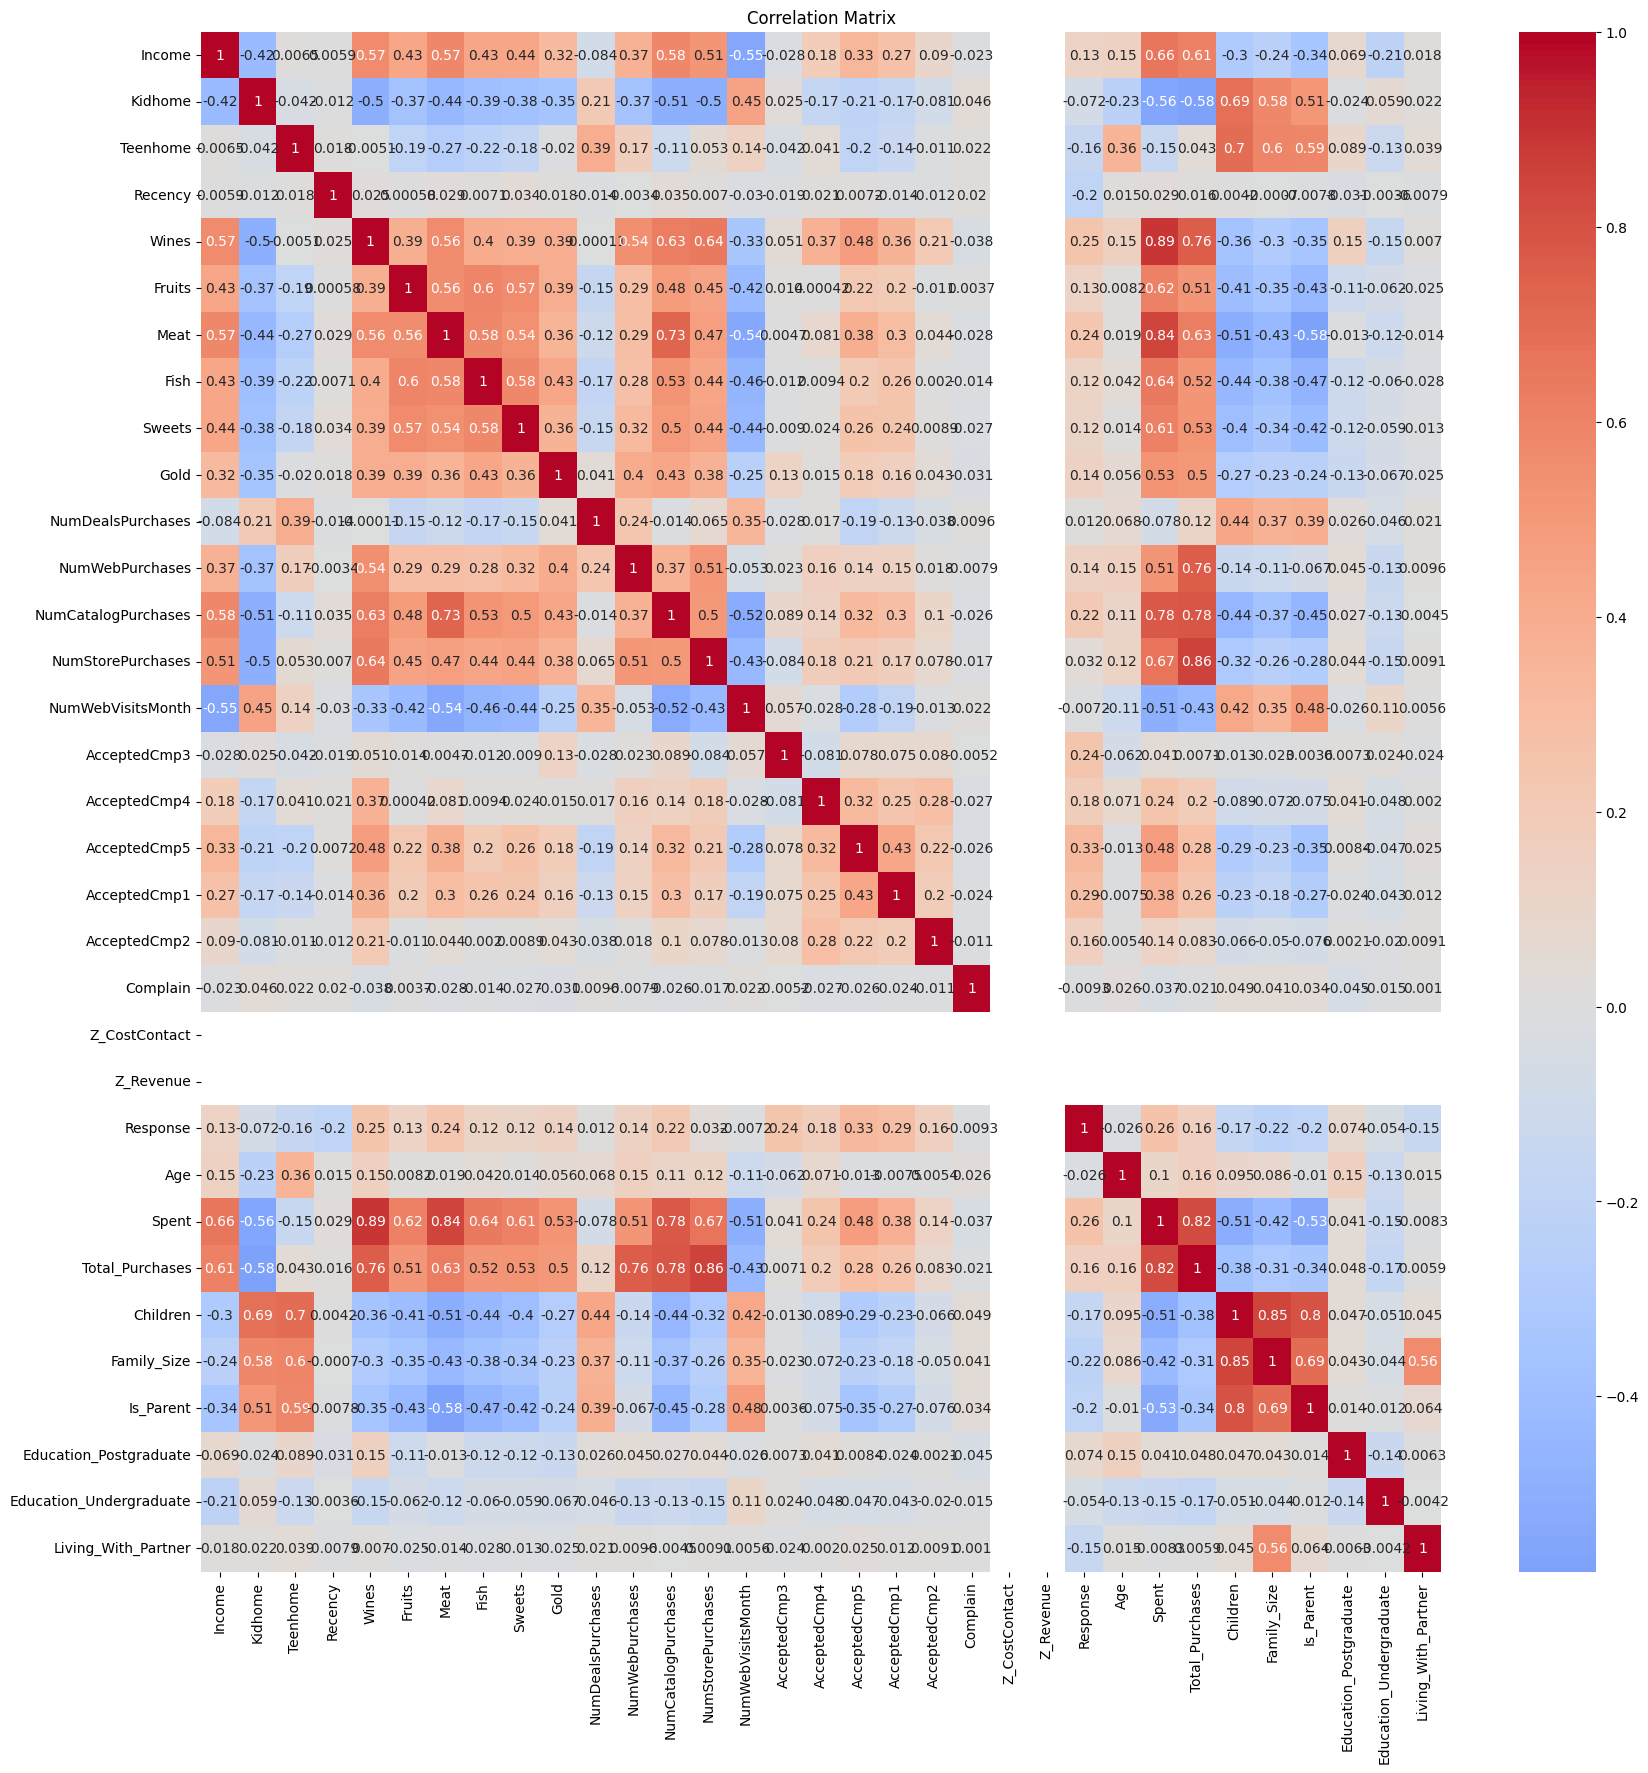

In [13]:
corrmat = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corrmat, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:

var_selector = VarianceThreshold(
    threshold=0.01
)

df_var = var_selector.fit_transform(df)

selected_features = df.columns[
    var_selector.get_support()
]
removed_features = df.columns[~var_selector.get_support()]
df = df[selected_features]
print("\n========== Variance Threshold Features ==========\n")
print(f'before = {df.shape[1]}')
print(selected_features)
print(f'after = {len(selected_features)}')
print(removed_features)


========== Variance Threshold Features ==========
before = 30
['Income', 'Kidhome', 'Teenhome', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Age', 'Spent', 'Total_Purchases', 'Children', 'Family_Size', 'Is_Parent', 'Education_Postgraduate', 'Education_Undergraduate', 'Living_With_Partner']
after  = 30
removed: ['Complain', 'Z_CostContact', 'Z_Revenue']


In [15]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Highly Correlated Features (dropped):", high_corr_features)

df = df.drop(columns=high_corr_features)

Highly Correlated Features (dropped): []


In [16]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("\nOriginal Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

print("\nExplained Variance Ratio:\n")
print(pca.explained_variance_ratio_)

Original Shape: (2016, 30)
Reduced Shape:  (2016, 21)
Explained Variance Ratio: [0.30854936 0.10459571 0.06469529 0.049851   0.04763675 0.0402217
 0.03496915 0.03424186 0.03321341 0.02850812 0.02671873 0.02408057
 0.02237405 0.02047199 0.01981118 0.01827752 0.01734789 0.01532082
 0.01479047 0.01447282 0.01380475]


In [ ]:
pca2 = PCA(n_components=3)

X_pca2 = pca2.fit_transform(X_scaled)

print("\nOriginal Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca2.shape)

print("\nExplained Variance Ratio:\n")
print(pca2.explained_variance_ratio_)

Original Shape: (2016, 30)
Reduced Shape:  (2016, 3)
Explained Variance Ratio: [0.30854936 0.10459571 0.06469529]


---
# ════════════════════════════════════════════
# MODEL 1 — K-Means  ·  Full Fine-Tuning
# ════════════════════════════════════════════
### Hyperparameters under search:
| Parameter | Values tested |
|---|---|
| `n_clusters` (k) | 2 → 10 |
| `init` | `k-means++`, `random` |
| `n_init` | 10, 20, 30 |
| `max_iter` | fixed = 500 |

**Total combinations: 9 × 2 × 3 = 54**

In [19]:
# ── KMeans Exhaustive Grid Search ──────────────────────────────────────────────

km_results = []

k_values      = range(2, 11)
init_values   = ['k-means++', 'random']
n_init_values = [10, 20, 30]

for k in k_values:
    for init in init_values:
        for n_init in n_init_values:
            km  = KMeans(n_clusters=k, init=init, n_init=n_init,
                         max_iter=500, random_state=42)
            lbl = km.fit_predict(X)

            km_results.append({
                'k'              : k,
                'init'           : init,
                'n_init'         : n_init,
                'silhouette'     : round(silhouette_score(X, lbl),    4),
                'davies_bouldin' : round(davies_bouldin_score(X, lbl), 4),
                'inertia'        : round(km.inertia_, 2),
                'n_iter'         : km.n_iter_
            })

km_df = pd.DataFrame(km_results).sort_values('silhouette', ascending=False)

print(f"Total combinations tested: {len(km_df)}")
print("\n── Top 10 by Silhouette ──")
print(km_df.head(10).to_string(index=False))

  File "c:\Users\basil\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\basil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\basil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                

Total combinations tested: 54

── Top 10 by Silhouette ──
 k      init  n_init  silhouette  davies_bouldin  inertia  n_iter
 2 k-means++      10      0.5064          0.7786 10598.46       8
 2 k-means++      20      0.5064          0.7786 10598.46       8
 2 k-means++      30      0.5064          0.7786 10598.46       8
 2    random      10      0.5063          0.7789 10598.40       4
 2    random      20      0.5063          0.7789 10598.40       4
 2    random      30      0.5063          0.7789 10598.40       4
 3 k-means++      10      0.4995          0.7144  6240.82       5
 3 k-means++      20      0.4995          0.7144  6240.82       5
 3 k-means++      30      0.4995          0.7144  6240.82       5
 3    random      20      0.4995          0.7144  6240.82       7


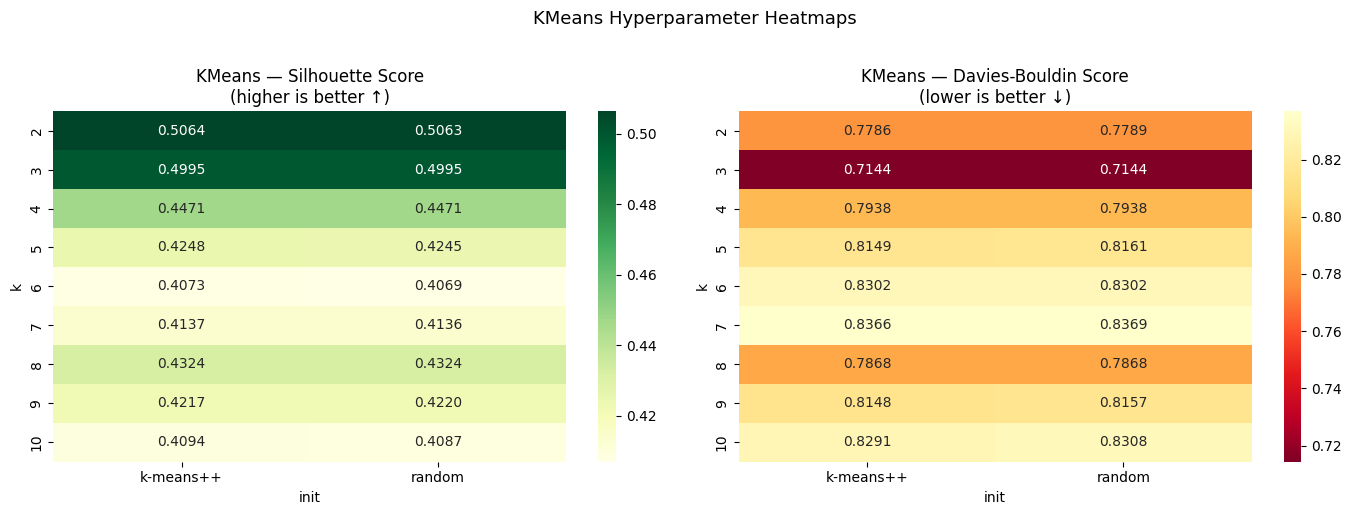

In [20]:
# ── Silhouette Heatmap  (k  ×  init) ──────────────────────────────────────────
# نأخذ أفضل n_init لكل (k, init)

pivot_sil = km_df.groupby(['k','init'])['silhouette'].max().unstack()
pivot_db  = km_df.groupby(['k','init'])['davies_bouldin'].min().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_sil, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0])
axes[0].set_title('KMeans — Silhouette Score\n(higher is better ↑)')
axes[0].set_xlabel('init')
axes[0].set_ylabel('k')

sns.heatmap(pivot_db, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=axes[1])
axes[1].set_title('KMeans — Davies-Bouldin Score\n(lower is better ↓)')
axes[1].set_xlabel('init')
axes[1].set_ylabel('k')

plt.suptitle('KMeans Hyperparameter Heatmaps', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

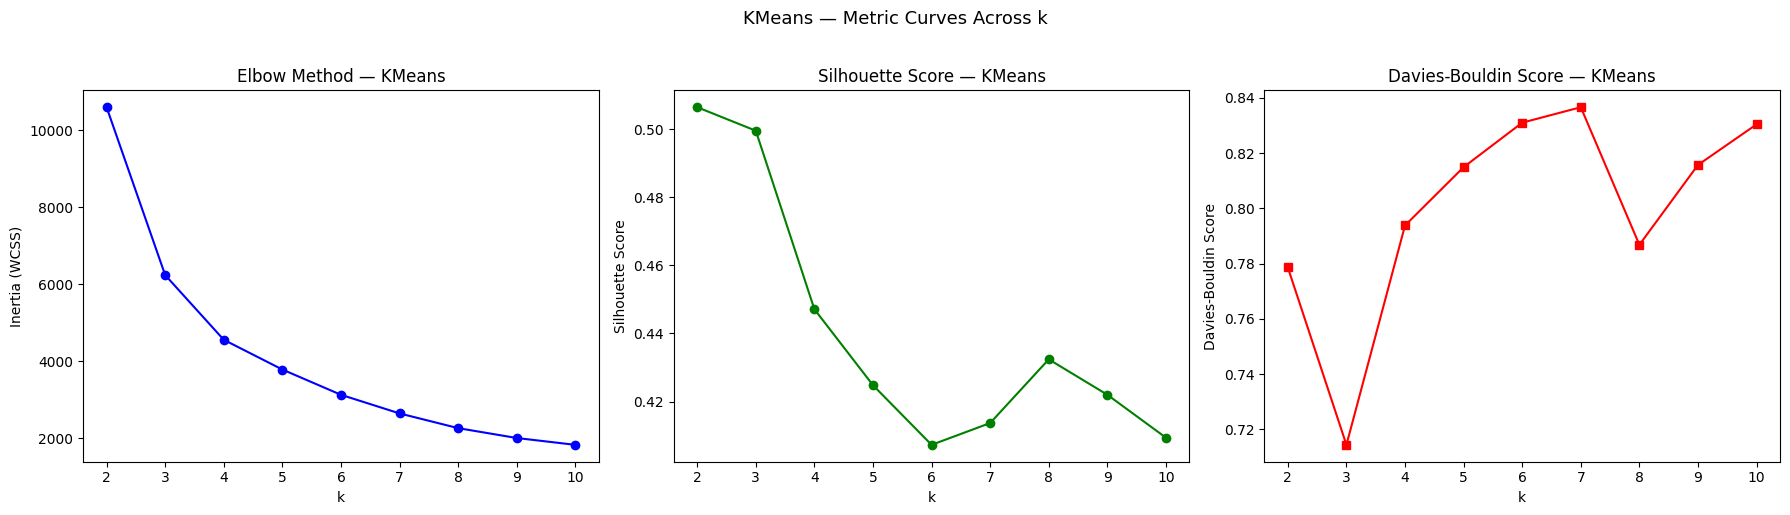

In [21]:
# ── Elbow + Silhouette line plots ──────────────────────────────────────────────

# best per k (best init + n_init)
best_per_k = km_df.sort_values('silhouette', ascending=False).groupby('k').first().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow
axes[0].plot(best_per_k['k'], best_per_k['inertia'], 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — KMeans')
axes[0].set_xticks(list(k_values))

# Silhouette
axes[1].plot(best_per_k['k'], best_per_k['silhouette'], 'go-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — KMeans')
axes[1].set_xticks(list(k_values))

# Davies-Bouldin
axes[2].plot(best_per_k['k'], best_per_k['davies_bouldin'], 'rs-')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score — KMeans')
axes[2].set_xticks(list(k_values))

plt.suptitle('KMeans — Metric Curves Across k', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Best config → k=2, init='k-means++', n_init=10
  Silhouette:     0.5064
  Davies-Bouldin: 0.7786  (lower is better)


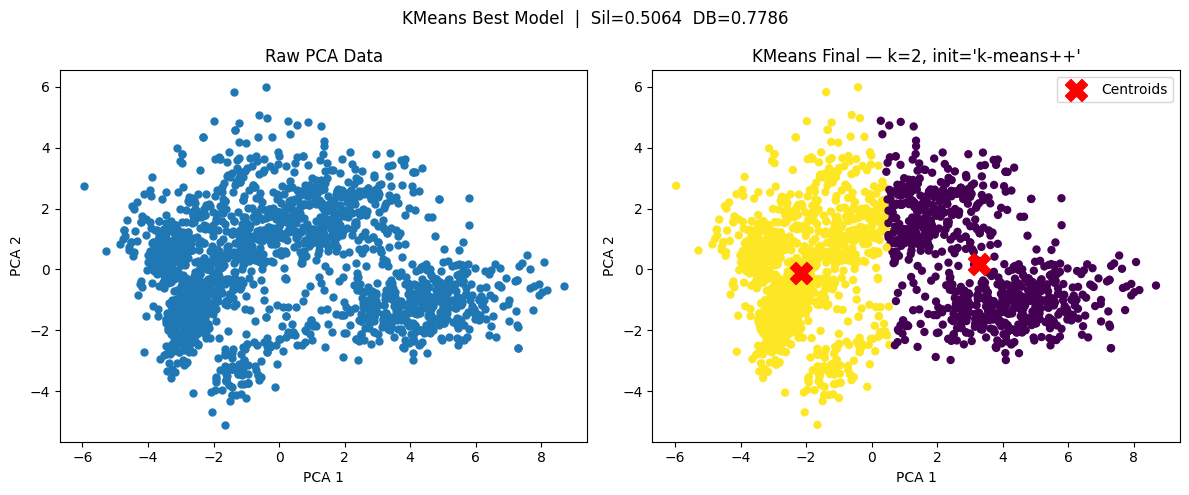


Cluster sizes: {0: 803, 1: 1213}


In [34]:
# ── Best KMeans — Final Fit & Visualisation ────────────────────────────────────

best_km = km_df.iloc[0]
print(f"Best config → k={int(best_km.k)}, init='{best_km.init}', n_init={int(best_km.n_init)}")
print(f"  Silhouette:     {best_km.silhouette}")
print(f"  Davies-Bouldin: {best_km.davies_bouldin}  (lower is better)")
# print(f"  Inertia:        {best_km.inertia_}")

kmeans_final = KMeans(
    n_clusters=int(best_km.k),
    init=best_km.init,
    n_init=int(best_km.n_init),
    max_iter=500,
    random_state=42
)
km_labels = kmeans_final.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], s=25)
axes[0].set_title('Raw PCA Data')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

axes[1].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis', s=25)
axes[1].scatter(kmeans_final.cluster_centers_[:, 0],
                kmeans_final.cluster_centers_[:, 1],
                c='red', marker='X', s=250, label='Centroids')
axes[1].set_title(f"KMeans Final — k={int(best_km.k)}, init='{best_km.init}'")
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend()

plt.suptitle(f"KMeans Best Model  |  Sil={best_km.silhouette}  DB={best_km.davies_bouldin}",
             fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nCluster sizes: {pd.Series(km_labels).value_counts().sort_index().to_dict()}")

---
# ════════════════════════════════════════════
# MODEL 2 — DBSCAN  ·  Full Fine-Tuning
# ════════════════════════════════════════════
### Hyperparameters under search:
| Parameter | Values tested |
|---|---|
| `eps` | 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.80, 1.00 |
| `min_samples` | 3, 5, 7, 10, 15, 20 |
| `metric` | `euclidean`, `manhattan` |

**Total combinations: 10 × 6 × 2 = 120**

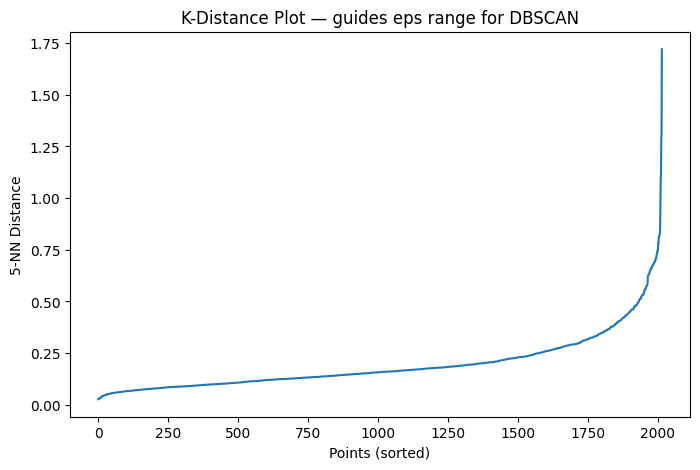

In [23]:
# ── K-Distance Plot to guide eps choice ───────────────────────────────────────

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X)
distances, _ = nn.kneighbors(X)
distances     = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Points (sorted)')
plt.ylabel('5-NN Distance')
plt.title('K-Distance Plot — guides eps range for DBSCAN')
plt.show()

In [24]:
# ── DBSCAN Exhaustive Grid Search ─────────────────────────────────────────────

db_results = []

eps_values        = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.80, 1.00]
min_samples_values = [3, 5, 7, 10, 15, 20]
metric_values     = ['euclidean', 'manhattan']

for eps in eps_values:
    for ms in min_samples_values:
        for metric in metric_values:
            db  = DBSCAN(eps=eps, min_samples=ms, metric=metric)
            lbl = db.fit_predict(X)
            n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)

            if n_cl >= 2:
                mask = lbl != -1
                if mask.sum() > 10:
                    db_results.append({
                        'eps'            : eps,
                        'min_samples'    : ms,
                        'metric'         : metric,
                        'n_clusters'     : n_cl,
                        'silhouette'     : round(silhouette_score(X[mask], lbl[mask]),     4),
                        'davies_bouldin' : round(davies_bouldin_score(X[mask], lbl[mask]), 4),
                        'noise_pct'      : round(100*(~mask).sum()/len(lbl), 1)
                    })

db_df = pd.DataFrame(db_results).sort_values('silhouette', ascending=False)

print(f"Valid combinations found: {len(db_df)} / {len(eps_values)*len(min_samples_values)*len(metric_values)}")
print("\n── Top 10 by Silhouette ──")
print(db_df.head(10).to_string(index=False))

Valid combinations found: 94 / 120

── Top 10 by Silhouette ──
 eps  min_samples    metric  n_clusters  silhouette  davies_bouldin  noise_pct
0.20           20 manhattan           2      0.8338          0.1854       91.6
0.25           20 euclidean           3      0.6409          0.3813       72.6
0.30           20 manhattan           4      0.6201          0.5871       72.8
0.15           15 manhattan           2      0.6161          0.5008       95.2
0.35           20 euclidean           2      0.5877          0.4837       35.0
0.30           15 manhattan          12      0.5835          0.6185       59.6
0.35           20 manhattan           9      0.5779          0.6474       61.0
0.30           20 euclidean           8      0.5548          0.6721       53.4
0.20           15 manhattan           3      0.5214          0.4913       84.5
0.20           10 manhattan          10      0.5167          0.4378       71.6


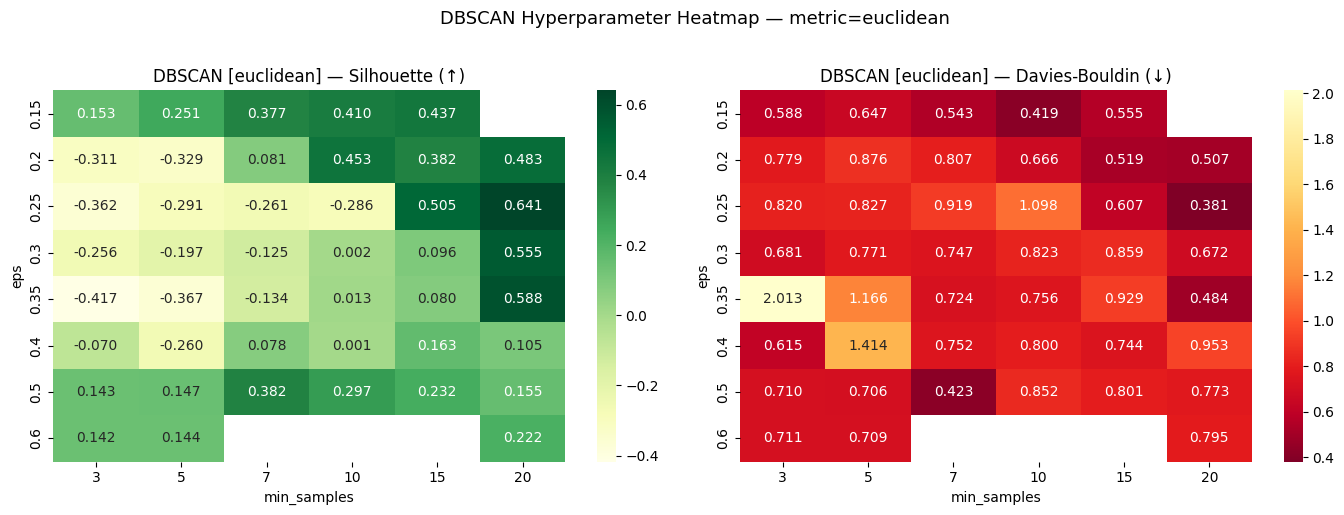

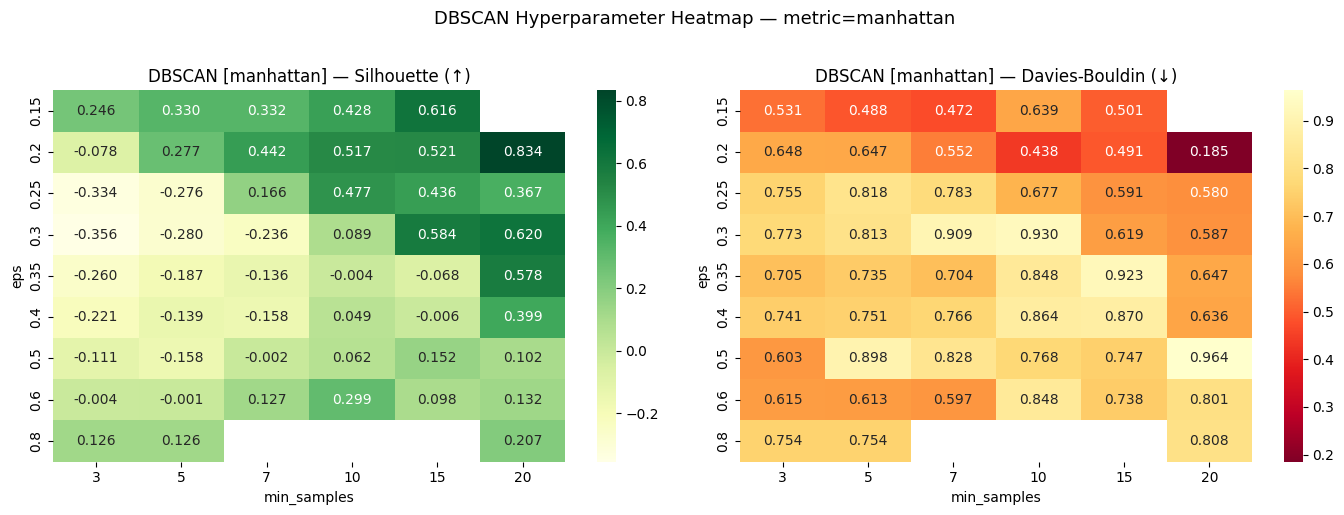

In [25]:
# ── DBSCAN Heatmaps (eps × min_samples) per metric ────────────────────────────

for metric in metric_values:
    sub = db_df[db_df['metric'] == metric]
    if sub.empty:
        continue

    pivot_sil = sub.pivot_table(index='eps', columns='min_samples',
                                values='silhouette', aggfunc='max')
    pivot_db  = sub.pivot_table(index='eps', columns='min_samples',
                                values='davies_bouldin', aggfunc='min')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0])
    axes[0].set_title(f'DBSCAN [{metric}] — Silhouette (↑)')

    sns.heatmap(pivot_db, annot=True, fmt='.3f', cmap='YlOrRd_r', ax=axes[1])
    axes[1].set_title(f'DBSCAN [{metric}] — Davies-Bouldin (↓)')

    plt.suptitle(f'DBSCAN Hyperparameter Heatmap — metric={metric}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

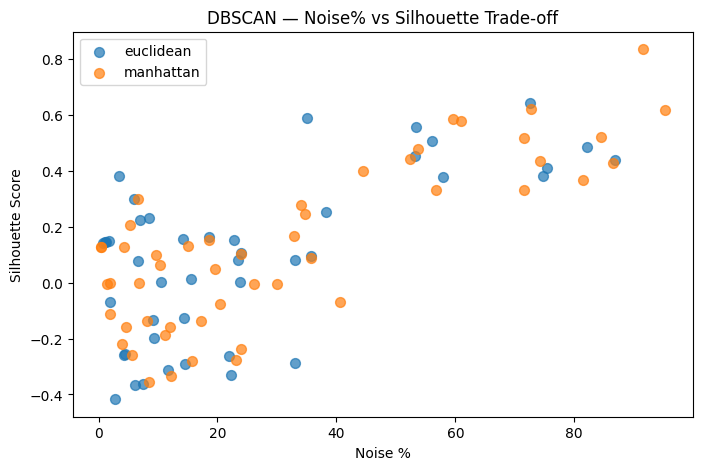

In [26]:
# ── Noise% vs Silhouette trade-off scatter ─────────────────────────────────────

plt.figure(figsize=(8, 5))
for metric, grp in db_df.groupby('metric'):
    plt.scatter(grp['noise_pct'], grp['silhouette'], label=metric, alpha=0.7, s=50)
plt.xlabel('Noise %')
plt.ylabel('Silhouette Score')
plt.title('DBSCAN — Noise% vs Silhouette Trade-off')
plt.legend()
plt.show()

Best config → eps=0.2, min_samples=20, metric='manhattan'
  Clusters:       2
  Silhouette:     0.8338
  Davies-Bouldin: 0.1854
  Noise:          91.6%


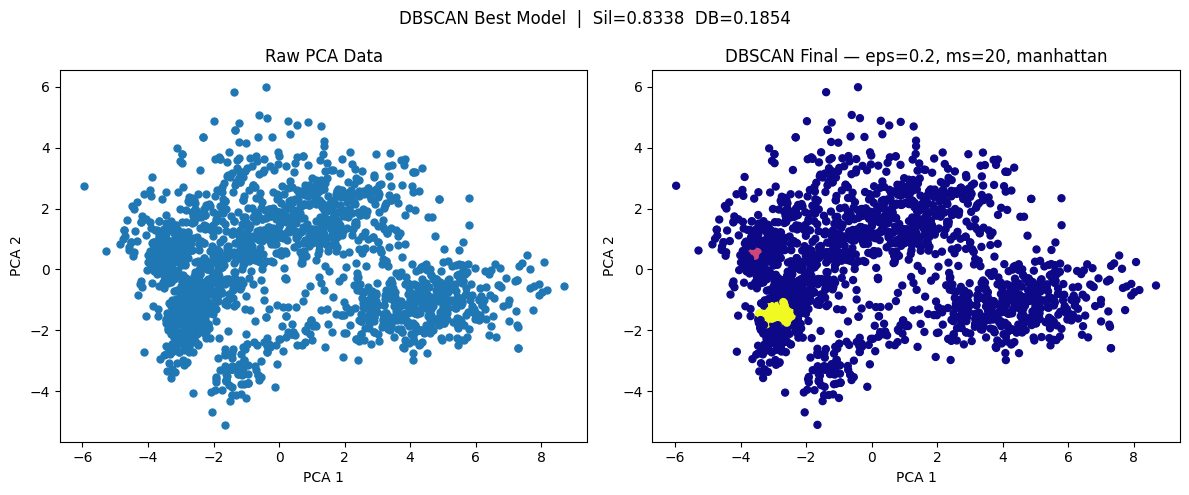


Cluster sizes (excl. noise): {0: 22, 1: 148}
Noise points: 1846 (91.6%)


In [27]:
# ── Best DBSCAN — Final Fit & Visualisation ────────────────────────────────────

best_db = db_df.iloc[0]
print(f"Best config → eps={best_db.eps}, min_samples={int(best_db.min_samples)}, metric='{best_db.metric}'")
print(f"  Clusters:       {int(best_db.n_clusters)}")
print(f"  Silhouette:     {best_db.silhouette}")
print(f"  Davies-Bouldin: {best_db.davies_bouldin}")
print(f"  Noise:          {best_db.noise_pct}%")

dbscan_final   = DBSCAN(eps=best_db.eps, min_samples=int(best_db.min_samples),
                        metric=best_db.metric)
db_labels_final = dbscan_final.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], s=25)
axes[0].set_title('Raw PCA Data')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

axes[1].scatter(X[:, 0], X[:, 1], c=db_labels_final, cmap='plasma', s=25)
axes[1].set_title(f"DBSCAN Final — eps={best_db.eps}, ms={int(best_db.min_samples)}, {best_db.metric}")
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')

plt.suptitle(f"DBSCAN Best Model  |  Sil={best_db.silhouette}  DB={best_db.davies_bouldin}",
             fontsize=12)
plt.tight_layout()
plt.show()

mask_final = db_labels_final != -1
print(f"\nCluster sizes (excl. noise): {pd.Series(db_labels_final[mask_final]).value_counts().sort_index().to_dict()}")
print(f"Noise points: {(~mask_final).sum()} ({best_db.noise_pct}%)")

---
# ════════════════════════════════════════════
# MODEL 3 — Agglomerative  ·  Full Fine-Tuning
# ════════════════════════════════════════════
### Hyperparameters under search:
| Parameter | Values tested |
|---|---|
| `n_clusters` | 2 → 10 |
| `linkage` | `ward`, `complete`, `average`, `single` |
| `metric` | `euclidean` (for ward) · `euclidean`, `manhattan`, `cosine` (others) |

**Total combinations: 9 × (1 + 3 + 3 + 3) = 90**

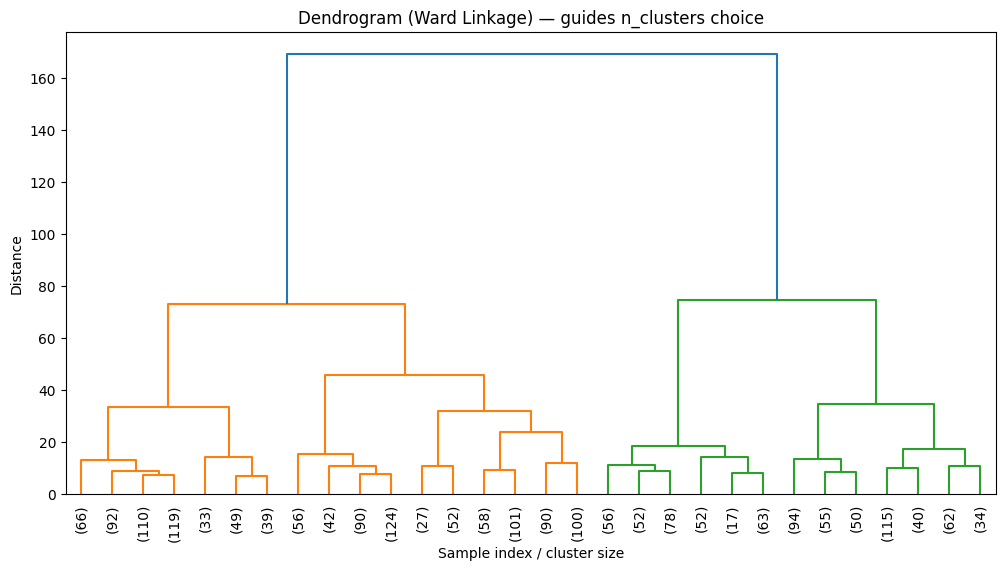

In [28]:
# ── Dendrogram ────────────────────────────────────────────────────────────────

plt.figure(figsize=(12, 6))
shc.dendrogram(
    shc.linkage(X, method='ward'),
    truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=10
)
plt.title('Dendrogram (Ward Linkage) — guides n_clusters choice')
plt.xlabel('Sample index / cluster size')
plt.ylabel('Distance')
plt.show()

In [29]:
# ── Agglomerative Exhaustive Grid Search ──────────────────────────────────────

agg_results = []

linkage_metric_map = {
    'ward'    : ['euclidean'],
    'complete': ['euclidean', 'manhattan', 'cosine'],
    'average' : ['euclidean', 'manhattan', 'cosine'],
    'single'  : ['euclidean', 'manhattan', 'cosine'],
}

for k in range(2, 11):
    for linkage, metrics in linkage_metric_map.items():
        for metric in metrics:
            agg  = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric=metric)
            lbl  = agg.fit_predict(X)

            agg_results.append({
                'k'              : k,
                'linkage'        : linkage,
                'metric'         : metric,
                'silhouette'     : round(silhouette_score(X, lbl),     4),
                'davies_bouldin' : round(davies_bouldin_score(X, lbl), 4)
            })

agg_df = pd.DataFrame(agg_results).sort_values('silhouette', ascending=False)

print(f"Total combinations tested: {len(agg_df)}")
print("\n── Top 10 by Silhouette ──")
print(agg_df.head(10).to_string(index=False))

Total combinations tested: 90

── Top 10 by Silhouette ──
 k  linkage    metric  silhouette  davies_bouldin
 2     ward euclidean      0.5047          0.7749
 2  average    cosine      0.4978          0.7975
 2 complete manhattan      0.4808          0.7486
 3 complete    cosine      0.4745          0.7629
 2  average manhattan      0.4735          0.6619
 2  average euclidean      0.4686          0.6708
 2 complete    cosine      0.4574          0.8408
 4  average manhattan      0.4473          0.6353
 4  average euclidean      0.4467          0.6346
 3     ward euclidean      0.4402          0.6825


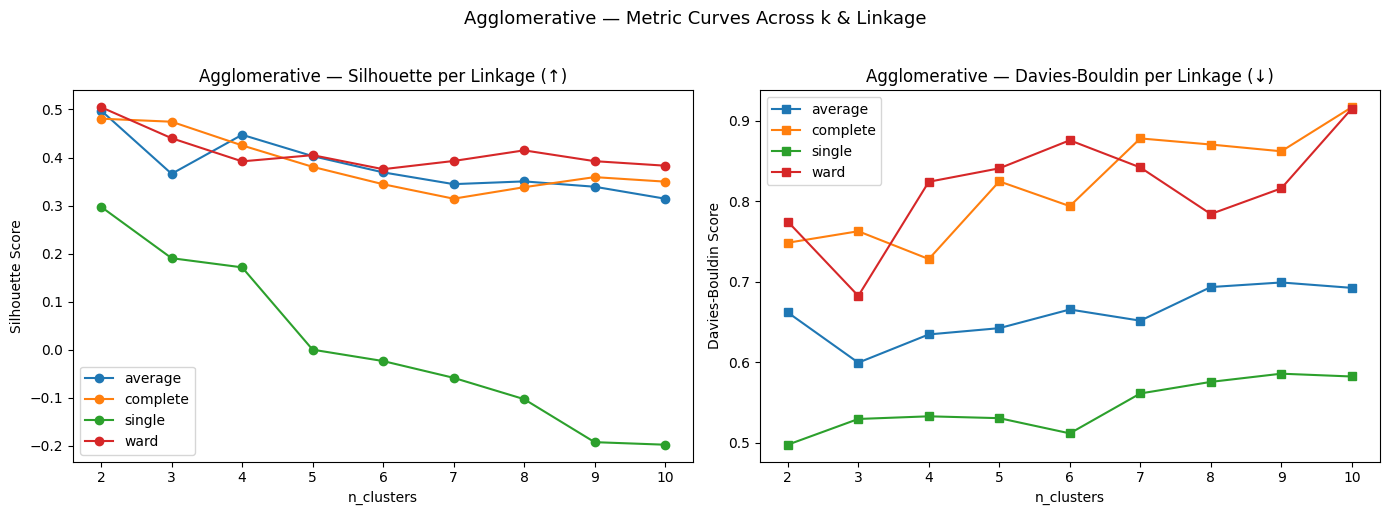

In [30]:
# ── Silhouette line per linkage strategy ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for linkage, grp in agg_df.groupby('linkage'):
    best = grp.groupby('k')['silhouette'].max().reset_index()
    axes[0].plot(best['k'], best['silhouette'], 'o-', label=linkage)

axes[0].set_xlabel('n_clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Agglomerative — Silhouette per Linkage (↑)')
axes[0].set_xticks(range(2, 11))
axes[0].legend()

for linkage, grp in agg_df.groupby('linkage'):
    best = grp.groupby('k')['davies_bouldin'].min().reset_index()
    axes[1].plot(best['k'], best['davies_bouldin'], 's-', label=linkage)

axes[1].set_xlabel('n_clusters')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Agglomerative — Davies-Bouldin per Linkage (↓)')
axes[1].set_xticks(range(2, 11))
axes[1].legend()

plt.suptitle('Agglomerative — Metric Curves Across k & Linkage', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

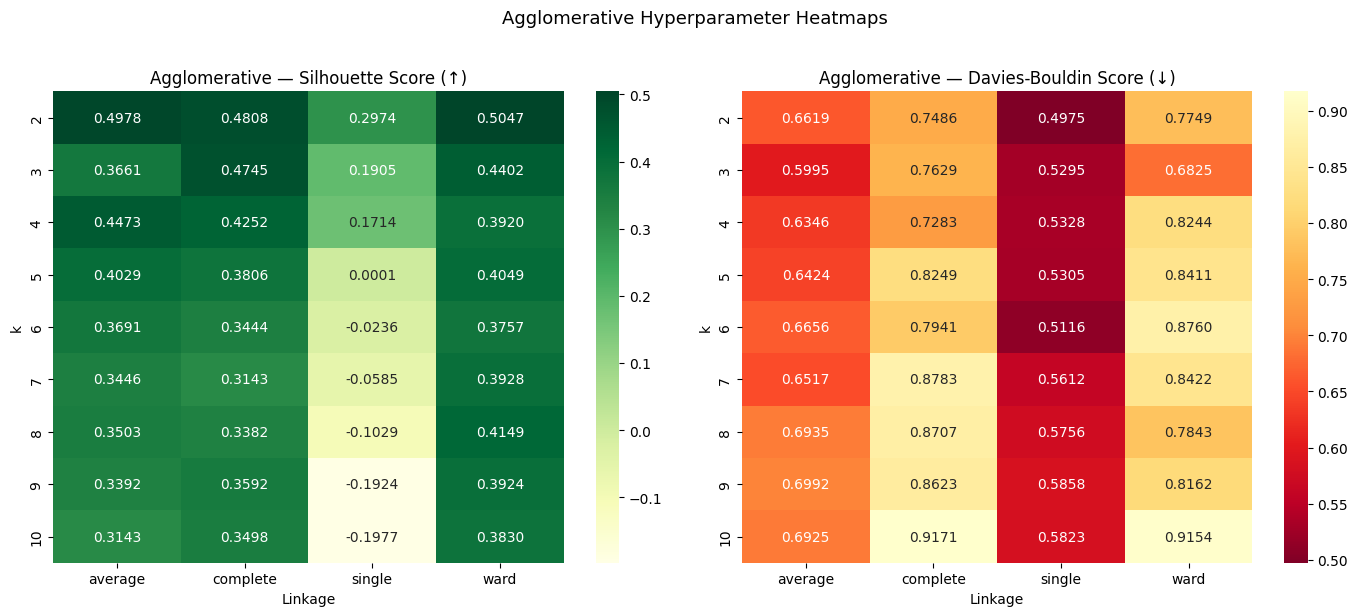

In [31]:
# ── Heatmap (k × linkage) ─────────────────────────────────────────────────────

pivot_sil_agg = agg_df.groupby(['k','linkage'])['silhouette'].max().unstack()
pivot_db_agg  = agg_df.groupby(['k','linkage'])['davies_bouldin'].min().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(pivot_sil_agg, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0])
axes[0].set_title('Agglomerative — Silhouette Score (↑)')
axes[0].set_xlabel('Linkage')
axes[0].set_ylabel('k')

sns.heatmap(pivot_db_agg, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=axes[1])
axes[1].set_title('Agglomerative — Davies-Bouldin Score (↓)')
axes[1].set_xlabel('Linkage')
axes[1].set_ylabel('k')

plt.suptitle('Agglomerative Hyperparameter Heatmaps', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Best config → k=2, linkage='ward', metric='euclidean'
  Silhouette:     0.5047
  Davies-Bouldin: 0.7749


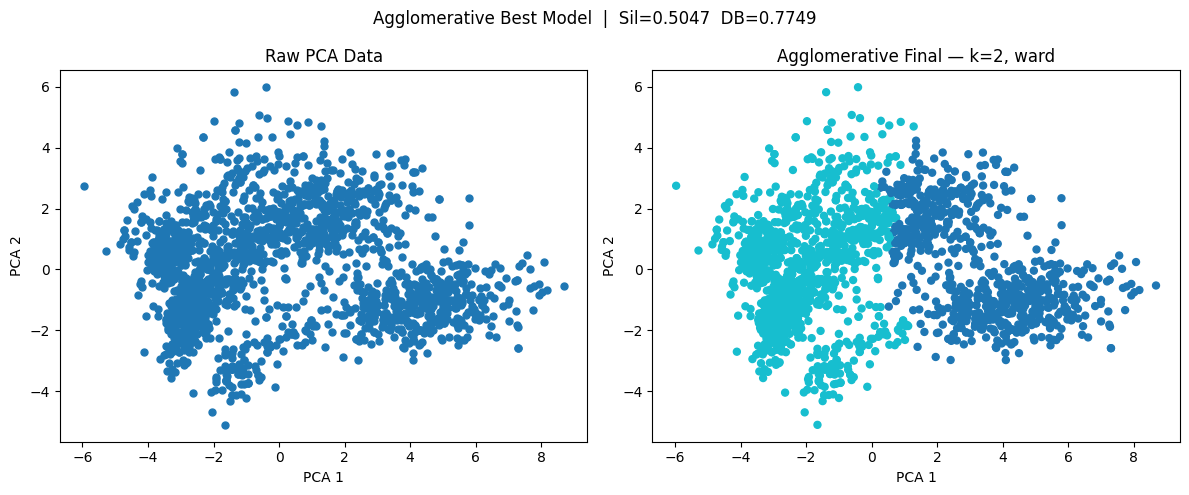


Cluster sizes: {0: 768, 1: 1248}


In [32]:
# ── Best Agglomerative — Final Fit & Visualisation ───────────────────────────

best_agg = agg_df.iloc[0]
print(f"Best config → k={int(best_agg.k)}, linkage='{best_agg.linkage}', metric='{best_agg.metric}'")
print(f"  Silhouette:     {best_agg.silhouette}")
print(f"  Davies-Bouldin: {best_agg.davies_bouldin}")

agg_final        = AgglomerativeClustering(
    n_clusters=int(best_agg.k),
    linkage=best_agg.linkage,
    metric=best_agg.metric
)
agg_labels_final = agg_final.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], s=25)
axes[0].set_title('Raw PCA Data')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

axes[1].scatter(X[:, 0], X[:, 1], c=agg_labels_final, cmap='tab10', s=25)
axes[1].set_title(f"Agglomerative Final — k={int(best_agg.k)}, {best_agg.linkage}")
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')

plt.suptitle(f"Agglomerative Best Model  |  Sil={best_agg.silhouette}  DB={best_agg.davies_bouldin}",
             fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nCluster sizes: {pd.Series(agg_labels_final).value_counts().sort_index().to_dict()}")

---
# ════════════════════════════════════════════
# Final Comparison — All 3 Best Models
# ════════════════════════════════════════════

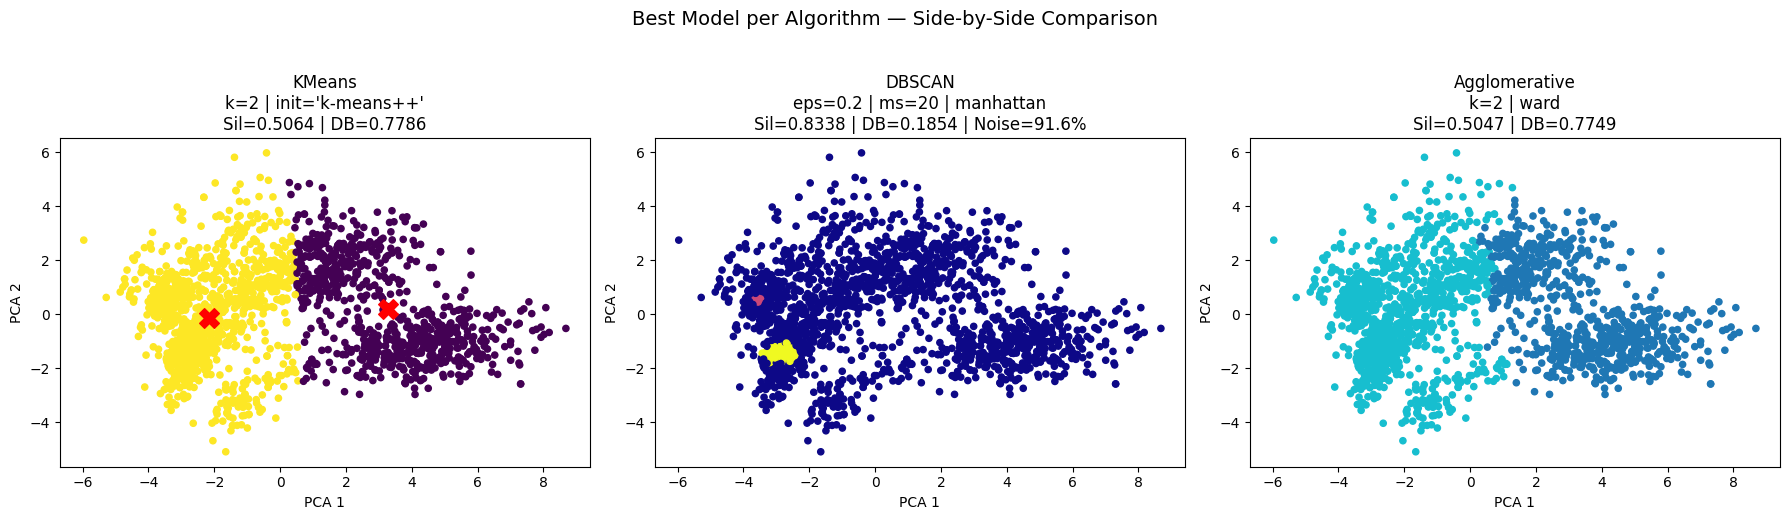

In [35]:
# ── Side-by-side cluster plots ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans
axes[0].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis', s=20)
axes[0].scatter(kmeans_final.cluster_centers_[:, 0],
                kmeans_final.cluster_centers_[:, 1],
                c='red', marker='X', s=200)
axes[0].set_title(f"KMeans\nk={int(best_km.k)} | init='{best_km.init}'\n"
                  f"Sil={best_km.silhouette} | DB={best_km.davies_bouldin}")
axes[0].set_xlabel('PCA 1'); axes[0].set_ylabel('PCA 2')

# DBSCAN
axes[1].scatter(X[:, 0], X[:, 1], c=db_labels_final, cmap='plasma', s=20)
axes[1].set_title(f"DBSCAN\neps={best_db.eps} | ms={int(best_db.min_samples)} | {best_db.metric}\n"
                  f"Sil={best_db.silhouette} | DB={best_db.davies_bouldin} | Noise={best_db.noise_pct}%")
axes[1].set_xlabel('PCA 1'); axes[1].set_ylabel('PCA 2')

# Agglomerative
axes[2].scatter(X[:, 0], X[:, 1], c=agg_labels_final, cmap='tab10', s=20)
axes[2].set_title(f"Agglomerative\nk={int(best_agg.k)} | {best_agg.linkage}\n"
                  f"Sil={best_agg.silhouette} | DB={best_agg.davies_bouldin}")
axes[2].set_xlabel('PCA 1'); axes[2].set_ylabel('PCA 2')

plt.suptitle('Best Model per Algorithm — Side-by-Side Comparison',
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

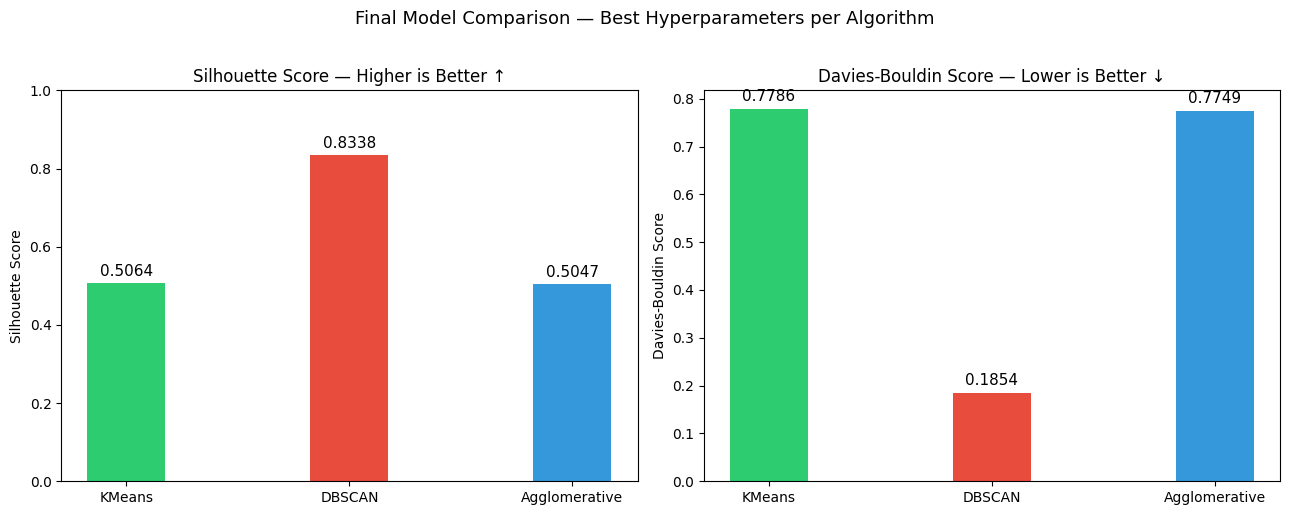

In [36]:
# ── Bar chart comparison ───────────────────────────────────────────────────────

sil_db_score = best_db.silhouette   # computed on non-noise points
db_db_score  = best_db.davies_bouldin

models   = ['KMeans', 'DBSCAN', 'Agglomerative']
sil_vals = [best_km.silhouette, sil_db_score, best_agg.silhouette]
db_vals  = [best_km.davies_bouldin, db_db_score, best_agg.davies_bouldin]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(x, sil_vals, width, color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score — Higher is Better ↑')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, sil_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)

bars2 = axes[1].bar(x, db_vals, width, color=['#2ecc71','#e74c3c','#3498db'])
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score — Lower is Better ↓')
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
for bar, val in zip(bars2, db_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Final Model Comparison — Best Hyperparameters per Algorithm',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# ── Summary Table ─────────────────────────────────────────────────────────────

summary = pd.DataFrame({
    'Model'             : ['KMeans', 'DBSCAN', 'Agglomerative'],
    'Best Params'       : [
        f"k={int(best_km.k)}, init='{best_km.init}', n_init={int(best_km.n_init)}",
        f"eps={best_db.eps}, min_samples={int(best_db.min_samples)}, metric='{best_db.metric}'",
        f"k={int(best_agg.k)}, linkage='{best_agg.linkage}', metric='{best_agg.metric}'"
    ],
    'n_clusters'        : [int(best_km.k), int(best_db.n_clusters), int(best_agg.k)],
    'Silhouette ↑'      : [best_km.silhouette,  sil_db_score,  best_agg.silhouette],
    'Davies-Bouldin ↓'  : [best_km.davies_bouldin, db_db_score, best_agg.davies_bouldin],
    'Notes'             : [
        'Needs k upfront — stable & fast',
        f"Noise={best_db.noise_pct}% — detects outliers automatically",
        'Hierarchy-based — no centroid needed'
    ]
})

print(summary.to_string(index=False))

        Model                                 Best Params  n_clusters  Silhouette ↑  Davies-Bouldin ↓                                        Notes
       KMeans            k=2, init='k-means++', n_init=10           2        0.5064            0.7786              Needs k upfront — stable & fast
       DBSCAN eps=0.2, min_samples=20, metric='manhattan'           2        0.8338            0.1854 Noise=91.6% — detects outliers automatically
Agglomerative     k=2, linkage='ward', metric='euclidean'           2        0.5047            0.7749         Hierarchy-based — no centroid needed
